# Community structure on the Ising J graph

Runs on the **production weighted species@item PL model** (`loaders.build_species_item_model` with the shipped `reg-m-a-species-item-weighted` knobs). The Ising J matrix is a signed weighted graph over (species, item) features — `+J` edges are synergies (want to be on the same team), `−J` edges are competitions (want to *not* be on the same team). Pair-level analysis was already validated; the natural abstraction up is **groups**:

- **+J communities = archetype groups** — features that mutually synergize.
- **−J communities = role pools** — features that compete for the same slot.

We run Louvain modularity-maximization on each signed subgraph separately. Then cross-tabulate: features sharing a +J community AND a −J community are intra-archetype substitutes (Pelipper/Politoed); features sharing a −J community but in different +J communities are **cross-archetype substitutes** (Torkoal/Pelipper, if recoverable).

**Pair-vocab caveat: structural exclusions.** On the (species, item) vocabulary, two features can be *rule*-excluded rather than *preference*-excluded: features sharing a species (species clause) or a held item (item clause) can never co-occur, so the fit assigns them large negative couplings that say nothing about the meta. Those pairs are masked out of the −J analysis and the visualization below; what remains is genuine cross-feature role competition.

(History: this notebook originally ran on the Gaussian chaos-JSON model, which systematically under-magnitudes strong negative couplings — the −J side was expected to be its weak half. The PL fit removes that specific caveat.)


In [24]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from k2dex.loaders import build_species_item_model

RNG_SEED = 0
PR_TAU, PR_MULT, PR_LAM = 30.0, 2.0, 3.0  # production weighted species@item knobs

(vocab, m, J, h, _, species_of, item_of, latest_date) = build_species_item_model(
    lam=PR_LAM, recency_tau=PR_TAU, in_person_multiplier=PR_MULT,
)
n = len(vocab)
iu, ju = np.triu_indices_from(J, k=1)
name_to_idx = {name: i for i, name in enumerate(vocab)}

# Structural exclusions: two (species, item) features can never co-occur when
# they share a species (species clause) or a non-None item (item clause), so
# their negative couplings are rule-driven, not preference-driven.
species_arr = np.array(species_of)
item_arr = np.array([it if it is not None else "" for it in item_of])
structural = (species_arr[iu] == species_arr[ju]) | (
    (item_arr[iu] == item_arr[ju]) & (item_arr[iu] != ""))

print(f"model:   weighted species@item (tau={PR_TAU:g}, x{PR_MULT:g}, lambda={PR_LAM:g})")
print(f"corpus through: {latest_date[:10]}")
print(f"vocab:   {n}")
print(f"J range: [{J.min():.3f}, {J.max():.3f}]")
print(f"structural pairs: {int(structural.sum())} of {len(iu)} ({structural.mean():.2%})")


model:   weighted species@item (tau=30, x2, lambda=3)
corpus through: 2026-06-10
vocab:   635
J range: [-5.857, 4.102]
structural pairs: 11942 of 201295 (5.93%)


## +J archetype communities

Build the positive-J subgraph (edges only where `J[i,j] > 0`, weighted by J magnitude). Run Louvain — it returns a partition that maximizes weighted modularity. Each community is a set of features that mutually synergize: a team archetype.

No threshold needed for +J — synergies are sparser than competitions, so the graph isn't pathologically dense. No structural masking needed either: rule-excluded pairs have strongly *negative* fitted couplings, so they can't contaminate the positive subgraph.


In [25]:
G_pos = nx.Graph()
G_pos.add_nodes_from(range(n))
for k in range(len(iu)):
    a, b = iu[k], ju[k]
    if J[a, b] > 0:
        G_pos.add_edge(a, b, weight=float(J[a, b]))

print(f"+J subgraph: {G_pos.number_of_nodes()} nodes, {G_pos.number_of_edges()} edges")

archetypes = sorted(
    nx.community.louvain_communities(G_pos, weight="weight", seed=RNG_SEED),
    key=len,
    reverse=True,
)
print(f"found {len(archetypes)} +J communities\n")

# Per-Pokémon archetype membership for later cross-tab
arch_of = np.full(n, -1, dtype=int)
for cid, c in enumerate(archetypes):
    for x in c:
        arch_of[x] = cid

for cid, c in enumerate(archetypes):
    top = sorted(c, key=lambda x: -m[x])[:10]
    print(f"archetype {cid:>2} (n={len(c):>2}): " + ", ".join(f"{vocab[x]} ({m[x]*100:.1f}%)" for x in top))

+J subgraph: 635 nodes, 16190 edges
found 9 +J communities

archetype  0 (n=122): Kingambit @ Black Glasses (15.4%), Farigiraf @ Sitrus Berry (8.2%), Torkoal @ Charcoal (4.7%), Kangaskhan @ Kangaskhanite (4.2%), Farigiraf @ Colbur Berry (3.5%), Blastoise @ Blastoisinite (3.3%), Vivillon @ Focus Sash (1.6%), Vivillon @ Choice Scarf (1.4%), Camerupt @ Cameruptite (1.4%), Sinistcha @ Occa Berry (1.4%)
archetype  1 (n=99): Garchomp @ Sitrus Berry (12.6%), Sinistcha @ Sitrus Berry (9.0%), Tyranitar @ Tyranitarite (8.5%), Incineroar @ Chople Berry (6.9%), Venusaur @ Venusaurite (6.2%), Whimsicott @ Fairy Feather (5.0%), Glimmora @ Focus Sash (5.0%), Corviknight @ Leftovers (4.7%), Excadrill @ Focus Sash (4.1%), Kommo-O @ Leftovers (4.0%)
archetype  2 (n=92): Basculegion @ Choice Scarf (21.2%), Archaludon @ Leftovers (10.5%), Basculegion @ Focus Sash (8.9%), Basculegion @ Mystic Water (8.1%), Dragonite @ Dragoninite (7.6%), Pelipper @ Focus Sash (6.5%), Pelipper @ Sitrus Berry (5.2%), Scovill

## −J role-pool communities

Build the negative-J subgraph (edges where `J[i,j] < 0`, weighted by `−J` magnitude), **after masking structural exclusions** (same-species and same-item pairs — their negative couplings encode the game rules, not the meta, and they would otherwise dominate the top of the −J distribution and organize the "pools" around item identity and species variants).

Threshold the remainder by quantile: the raw −J graph is nearly complete (every pair has *some* weak competition because team slots are finite), and Louvain on a near-complete graph collapses to one or two giant blobs. Thresholding to the top 5% of non-structural −J magnitudes lets community structure emerge.

**Expectation, calibrated.** Competition in team-building is broader than role-substitution: two features can mutually depress each other's appearance probability for many reasons — same role, same archetype slot, team-size budget pressure — and the fit pools all of those. Clean role pools should emerge for sharply-defined slots (weather setter, Trick Room setter, the Mega slot); diffuse competition gets averaged in. The pair vocabulary adds a genuinely new readout the species model couldn't express: *cross-species item-role competition* (e.g. different species' Sash-lead variants competing for the same slot) survives the masking because the species and item both differ.


In [85]:
neg_mask = (J[iu, ju] < 0) & ~structural
neg_J_values = -J[iu, ju][neg_mask]
threshold = np.quantile(neg_J_values, 0.98)
print(f"-J threshold (99th pct of non-structural negatives): {threshold:.4f}")
print(f"structural negatives masked: {int(((J[iu, ju] < 0) & structural).sum())}")

G_neg = nx.Graph()
G_neg.add_nodes_from(range(n))
for k in np.flatnonzero(neg_mask):
    a, b = int(iu[k]), int(ju[k])
    if -J[a, b] > threshold:
        G_neg.add_edge(a, b, weight=float(-J[a, b]))

isolated = [v for v, d in G_neg.degree() if d == 0]
print(f"-J subgraph (thresholded): {G_neg.number_of_nodes() - len(isolated)} connected nodes, {G_neg.number_of_edges()} edges, {len(isolated)} isolated\n")

role_pools = sorted(
    [c for c in nx.community.louvain_communities(G_neg, weight="weight", seed=RNG_SEED) if len(c) > 1],
    key=len,
    reverse=True,
)
print(f"found {len(role_pools)} -J communities (size > 1)\n")

pool_of = np.full(n, -1, dtype=int)
for cid, c in enumerate(role_pools):
    for x in c:
        pool_of[x] = cid

for cid, c in enumerate(role_pools):
    top = sorted(c, key=lambda x: -m[x])[:10]
    print(f"pool {cid:>2} (n={len(c):>2}): " + ", ".join(f"{vocab[x]} ({m[x]*100:.1f}%)" for x in top))


-J threshold (99th pct of non-structural negatives): 0.6706
structural negatives masked: 11937
-J subgraph (thresholded): 431 connected nodes, 3464 edges, 204 isolated

found 6 -J communities (size > 1)

pool  0 (n=174): Sneasler @ White Herb (30.1%), Basculegion @ Choice Scarf (21.2%), Eternal Flower Floette @ Floettite (21.0%), Sylveon @ Fairy Feather (10.6%), Glimmora @ Focus Sash (5.0%), Clefable @ Sitrus Berry (0.8%), Farigiraf @ Mental Herb (0.7%), Hatterene @ Fairy Feather (0.6%), Alolan Ninetales @ Choice Scarf (0.6%), Oranguru @ Colbur Berry (0.5%)
pool  1 (n=86): Kingambit @ Chople Berry (20.7%), Incineroar @ Sitrus Berry (16.3%), Kingambit @ Black Glasses (15.4%), Sneasler @ Focus Sash (7.4%), Incineroar @ Chople Berry (6.9%), Corviknight @ Leftovers (4.7%), Sableye @ Roseli Berry (4.1%), Aegislash @ Spell Tag (3.1%), Aegislash @ Focus Sash (1.6%), Kingambit @ Focus Sash (1.5%)
pool  2 (n=53): Garchomp @ Sitrus Berry (12.6%), Archaludon @ Leftovers (10.5%), Garchomp @ Choice

## Cross-tabulation: archetype × role pool

For each feature we now have two community labels:

- archetype (+J community) — what kind of team it goes on
- role pool (−J community) — what other features compete with it for a slot

The contingency table reveals different structural cases:

- A **single (archetype, pool) cell** with many features = intra-archetype substitutes (sand sweepers within the sand archetype).
- A **pool spanning multiple archetypes** = cross-archetype substitutes (weather setters across weather archetypes; same-item leads across all archetypes).
- An **archetype spanning multiple pools** = internally-differentiated archetype (different roles within sand).

This is the structural answer to the role-vs-archetype question we kept hitting earlier. Because same-species and same-item pairs are masked, every pool here is *cross-species, cross-item* role competition — the trivial "Incineroar variants substitute for each other" pools are excluded by construction.


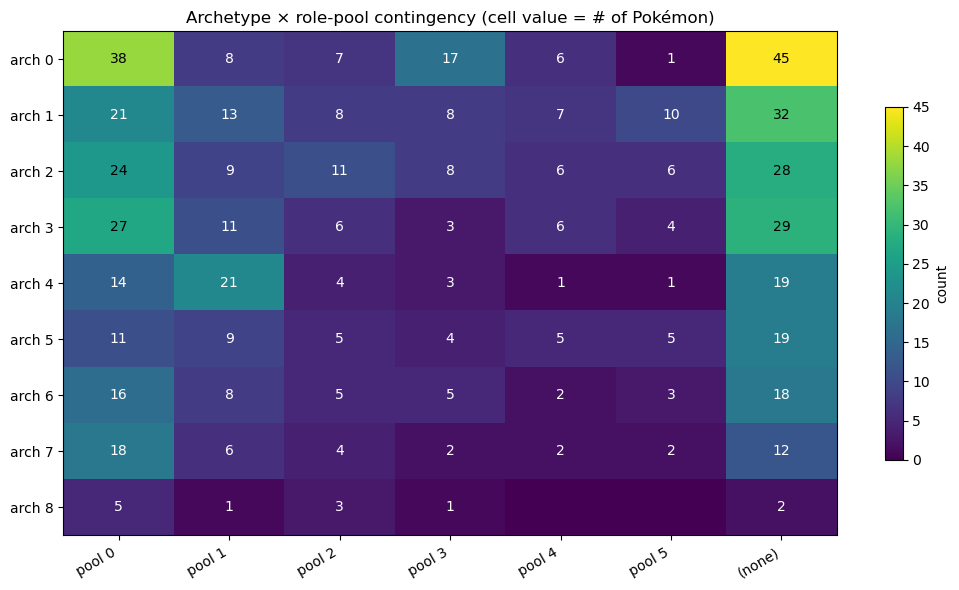

Pools spanning multiple archetypes (cross-archetype substitute pools):

  pool 0  (spans 9 archetypes):
    from arch 0: Farigiraf @ Mental Herb, Hatterene @ Fairy Feather, Oranguru @ Colbur Berry, Gallade @ Focus Sash, Arcanine @ Sitrus Berry
    from arch 3: Clefable @ Sitrus Berry, Garchomp @ Yache Berry, Gardevoir @ Choice Scarf, Venusaur @ Leftovers, Venusaur @ Occa Berry
    from arch 2: Basculegion @ Choice Scarf, Espathra @ Sitrus Berry, Scizor @ Sitrus Berry, Pelipper @ Leftovers, Pikachu @ Light Ball
    from arch 1: Glimmora @ Focus Sash, Whimsicott @ Sitrus Berry, Tyranitar @ Choice Scarf, Gengar @ Focus Sash, Dragapult @ Dragon Fang
    from arch 7: Mimikyu @ Spell Tag, Steelix @ Steelixite, Hydreigon @ Haban Berry, Tsareena @ Miracle Seed, Mimikyu @ Fairy Feather
    from arch 6: Sylveon @ Fairy Feather, Sylveon @ Leftovers, Kommo-O @ Sitrus Berry, Talonflame @ Charcoal, Mamoswine @ Focus Sash
    from arch 4: Sneasler @ White Herb, Kingambit @ Lum Berry, Sneasler @ Sitru

In [86]:
# Build contingency table: rows = archetypes, cols = role pools (+ "none" for unpooled)
n_arch = len(archetypes)
n_pool = len(role_pools)
contingency = np.zeros((n_arch, n_pool + 1), dtype=int)
for i in range(n):
    arch = arch_of[i]
    pool = pool_of[i] if pool_of[i] >= 0 else n_pool
    contingency[arch, pool] += 1

col_labels = [f"pool {i}" for i in range(n_pool)] + ["(none)"]
row_labels = [f"arch {i}" for i in range(n_arch)]

fig, ax = plt.subplots(figsize=(max(8, 1.5 * (n_pool + 1)), max(6, 0.5 * n_arch)))
im = ax.imshow(contingency, cmap="viridis", aspect="auto")
ax.set_xticks(range(n_pool + 1)); ax.set_xticklabels(col_labels, rotation=30, ha="right")
ax.set_yticks(range(n_arch)); ax.set_yticklabels(row_labels)
for i in range(n_arch):
    for j in range(n_pool + 1):
        v = contingency[i, j]
        if v > 0:
            ax.text(j, i, str(v), ha="center", va="center",
                    color="white" if v < contingency.max() / 2 else "black", fontsize=10)
ax.set_title("Archetype × role-pool contingency (cell value = # of Pokémon)")
plt.colorbar(im, ax=ax, label="count", shrink=0.7)
plt.tight_layout()
plt.show()

# Highlight cross-archetype pools: pools that span >1 archetype
print("Pools spanning multiple archetypes (cross-archetype substitute pools):")
for pool_id, c in enumerate(role_pools):
    arch_breakdown = {}
    for x in c:
        a = arch_of[x]
        arch_breakdown.setdefault(a, []).append(x)
    if len(arch_breakdown) > 1:
        print(f"\n  pool {pool_id}  (spans {len(arch_breakdown)} archetypes):")
        for a, members in sorted(arch_breakdown.items(), key=lambda kv: -len(kv[1])):
            top = sorted(members, key=lambda x: -m[x])[:5]
            print(f"    from arch {a}: {', '.join(vocab[x] for x in top)}")

## Visualization: the Ising J graph colored by archetype

Filtered network graph (top 3% of non-structural |J| pairs), with nodes colored by their +J archetype membership. Blue solid edges = synergies, red dashed = competitions. Node size ∝ weighted usage. Visually surfaces both within-cluster cohesion (+J edges inside each archetype color) and cross-cluster competition (−J edges between colors). Structural exclusions are masked here too — without the mask the red edges would mostly be same-item/same-species rule artifacts.


viz graph: 543 nodes, 5681 edges


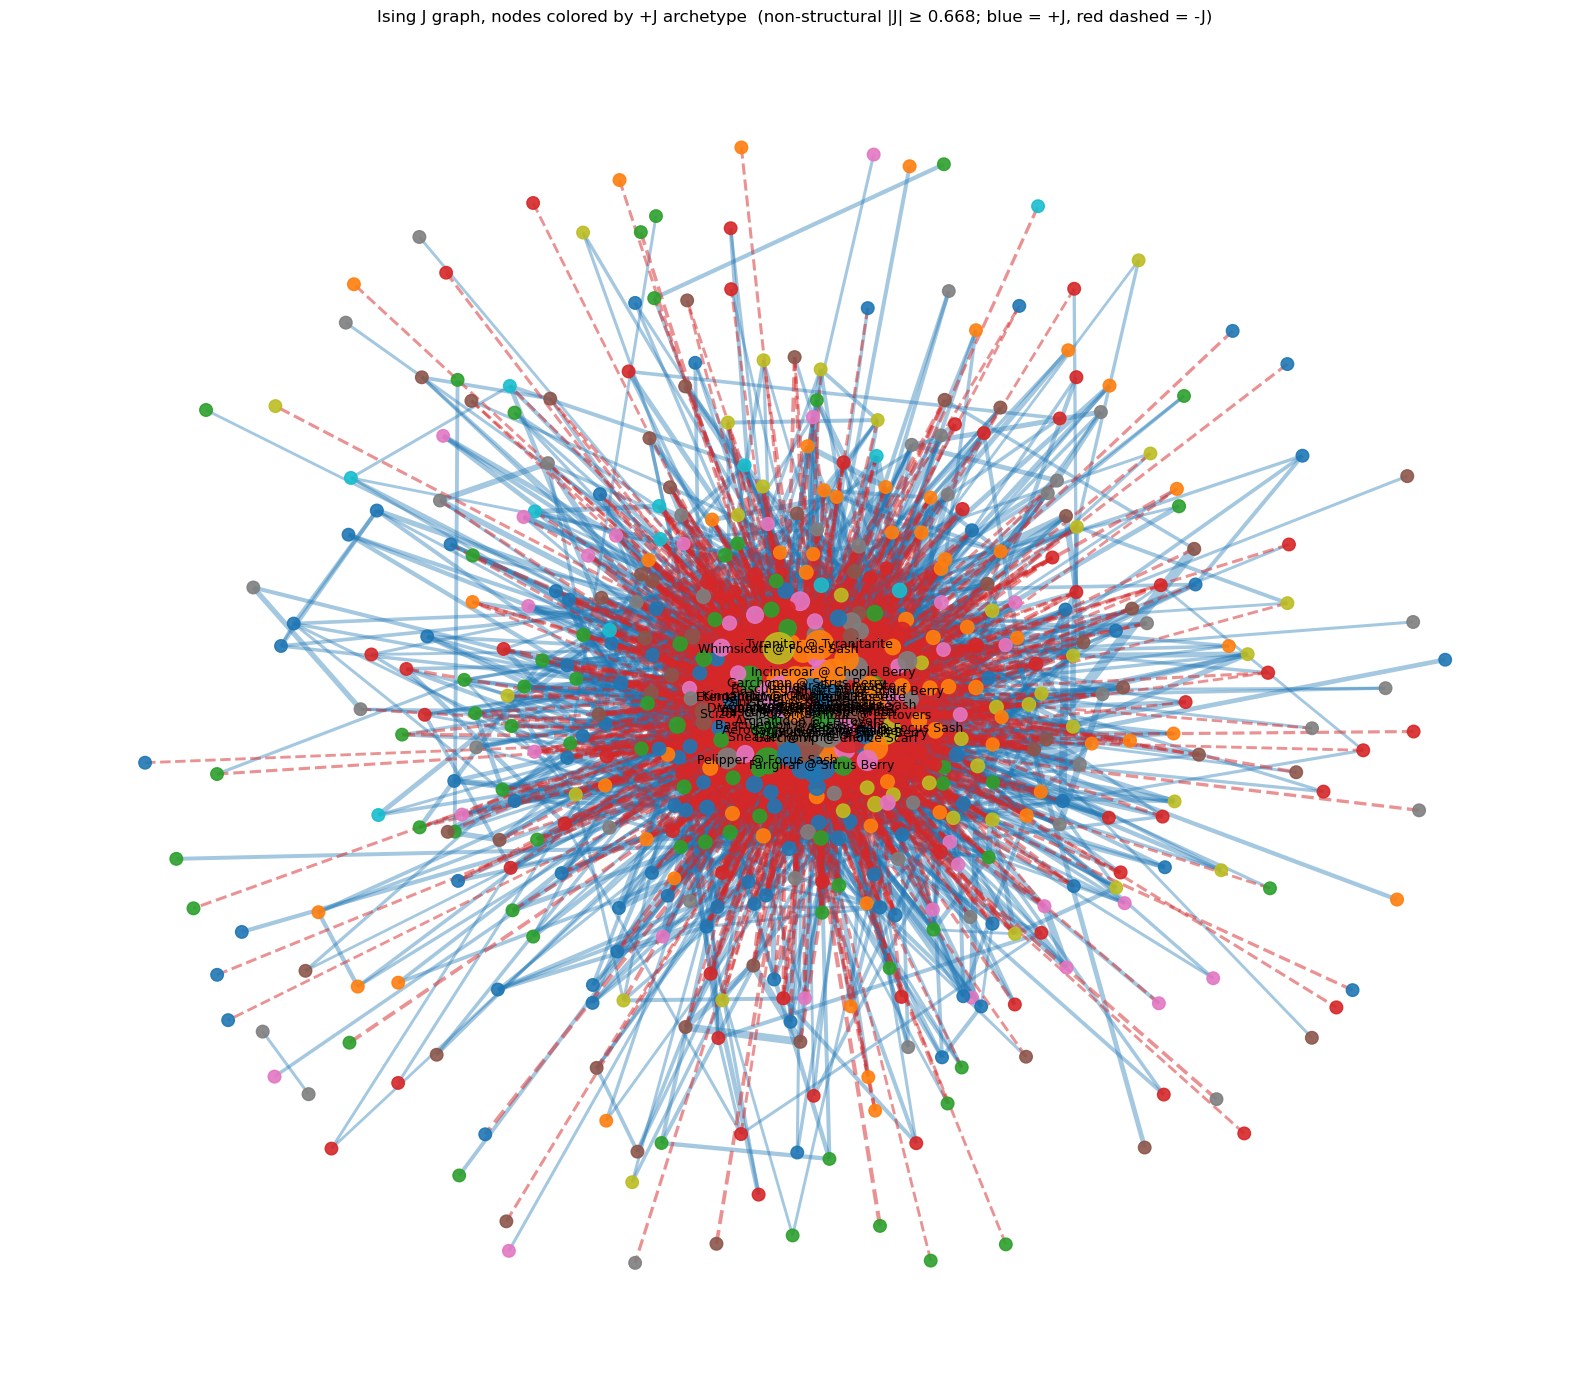

In [87]:
keep = ~structural
J_abs = np.abs(J[iu, ju][keep])
viz_thr = np.quantile(J_abs, 0.97)

G = nx.Graph()
for i in range(n):
    G.add_node(i, name=vocab[i], usage=m[i], arch=arch_of[i])
for k in np.flatnonzero(keep):
    a, b = int(iu[k]), int(ju[k])
    if abs(J[a, b]) >= viz_thr:
        G.add_edge(a, b, weight=float(J[a, b]), abs_weight=float(abs(J[a, b])))

isolated = [i for i, d in G.degree() if d == 0]
G_drawn = G.copy()
G_drawn.remove_nodes_from(isolated)
print(f"viz graph: {G_drawn.number_of_nodes()} nodes, {G_drawn.number_of_edges()} edges")

pos = nx.spring_layout(G_drawn, weight="abs_weight", k=0.6, iterations=100, seed=RNG_SEED)

edges_pos = [(u, v) for u, v, d in G_drawn.edges(data=True) if d["weight"] > 0]
edges_neg = [(u, v) for u, v, d in G_drawn.edges(data=True) if d["weight"] < 0]
pos_widths = [3 * abs(G_drawn[u][v]["weight"]) for u, v in edges_pos]
neg_widths = [3 * abs(G_drawn[u][v]["weight"]) for u, v in edges_neg]

node_sizes = [80 + 4000 * G_drawn.nodes[i]["usage"] for i in G_drawn.nodes()]
node_colors = [G_drawn.nodes[i]["arch"] for i in G_drawn.nodes()]

fig, ax = plt.subplots(figsize=(16, 14))
nx.draw_networkx_edges(G_drawn, pos, edgelist=edges_pos, edge_color="#1f77b4",
                       alpha=0.4, width=pos_widths, ax=ax)
nx.draw_networkx_edges(G_drawn, pos, edgelist=edges_neg, edge_color="#d62728",
                       alpha=0.5, width=neg_widths, style="dashed", ax=ax)
nodes = nx.draw_networkx_nodes(G_drawn, pos, node_size=node_sizes,
                               node_color=node_colors, cmap=plt.cm.tab10, alpha=0.9, ax=ax)

top_usage = sorted(G_drawn.nodes(), key=lambda i: -G_drawn.nodes[i]["usage"])[:30]
labels = {i: vocab[i] for i in top_usage}
nx.draw_networkx_labels(G_drawn, pos, labels=labels, font_size=9, ax=ax)

ax.set_title(f"Ising J graph, nodes colored by +J archetype  (non-structural |J| ≥ {viz_thr:.3f}; "
             f"blue = +J, red dashed = -J)")
ax.axis("off")
plt.tight_layout()
plt.show()
